# Learning curves: the HPC 100k comparison, and the local 10k study

Two run sets, because the questions "is any of these arms under- or over-trained",
"how long did each take", and "why is the force error larger than the local run's"
all need both.

**HPC** (`../deepmd/runs100k/<arm>/lcurve.out`) - the four deepmd arms of the cace
comparison: `sr` (short range only), `hyb_lrw1` and `hyb_lrw001` (learned local
charges, long-range weight 1.0 and 0.01), `freeze_spce` (fixed SPC/E charge
table). 100000 steps, `disp_freq 1000`, so 100 points each.

**Local** (`../../../01.train/rerun/extended/run_*/lcurve_*.out`) - the earlier
study on the FastLearn set: `ordinary` / `hybrid_q` / `hybrid_fixed`, replicates A
and B, plus a `decay_steps 7500` variant of each. 10000 steps, `disp_freq 100`,
100 points each.

Both were trained against the same kind of target (energy is the residual after
per-element references, forces in eV/A), but on **different datasets with
different force scales**, which is why the cross-study comparison below is done
in relative terms only.

## How to read these curves

1. **Every `rmse_*_val` point is a small random draw, not the held-out error.**
   The trainer re-samples the validation systems at each `disp_freq`: HPC
   `valid batch_size 4 x numb_btch 3` = 12 frames out of 159; local
   `batch_size 1 x numb_btch 3` = 3 frames out of 80. Consecutive points come
   from different checkpoints *and* different frames, so the point-to-point
   scatter is mostly sampling noise. Trends must be read over a window.
   The numbers that decide anything are the full-split ones, each arm averaged
   over its three latest checkpoints: `compare/metrics.py --late 3` for the HPC
   arms, `sweep_valid.tsv` for the local arms. FIG 1/2 and FIG 7 plot those
   held-out values as separate markers so the size of the bias is visible rather
   than asserted.
2. **`rmse_*_trn` is on one training batch** (4 frames for HPC), so the train
   curve is noisy for the same reason.
3. **The learning rate is a staircase, not a curve.** `deepmd`'s `exp` schedule is
   `lr = start_lr * decay_rate ** (step // decay_steps)` with
   `decay_rate = (stop_lr/start_lr) ** (decay_steps/stop_steps)`, and `decay_steps`
   is silently replaced by a default when it is `>= stop_steps`
   (`default_ds = 100 if stop_steps // 10 > 100 else stop_steps // 100 + 1`).
   Both studies used `start_lr 1e-3` and `stop_lr 3.51e-8`; they differ only in
   `decay_steps`, and that is the whole difference:
   - **HPC**: `decay_steps 100000`, equal to `stop_steps`, so the default 100 is
     substituted. The lr then steps down 1000 times, by 1.0% per 100 steps, and
     lands on `stop_lr` exactly at step 100000 - a staircase fine enough to read as
     a smooth curve (and the log is sampled every 1000 steps, so FIG 1's lower
     panel draws it smooth by construction). The run ends exactly where the
     schedule was designed to end.
   - **local**: `decay_steps 5000`, kept as written. Inside a 10000-step budget the
     schedule has just **two levels**: `1e-3` for steps 0-5000, then `5.9e-6` for
     everything after. `stop_lr` is never reached.
   That is the single biggest scheduling difference between the two studies, and
   FIG 1's lower panel is what it looks like.

In [1]:
"""Setup: palette, style, loaders. Jupyter runs this with cwd = this notebook's dir."""
import glob
import json
import os
import re

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline

# --- palette -----------------------------------------------------------------
# The dataviz reference instance, light mode. This four-hue set was validated,
# not eyeballed:
#   node scripts/validate_palette.js "#2a78d6,#eb6834,#1baf7a,#4a3aa7" \
#        --mode light --pairs all     -> ALL CHECKS PASS
#        (worst all-pairs CVD dE 9.2, normal-vision dE 16.3)
# Slot 4 (yellow #eda100) and slot 5 (magenta #e87ba4) were rejected: beside
# orange they score normal-vision dE 13.7 and 12.9, under the 15 floor as soon as
# every series is on screen at once - and the pair they would sit next to (the
# two learned arms) is exactly the pair a reader needs to tell apart.
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, INK2, INK3 = "#0b0b0b", "#52514e", "#8a8880"
SURFACE = "#fcfcfb"

# hue = the charge layer, the axis under study, so the same role keeps the same
# colour in every figure; linestyle = the secondary variant (long-range weight,
# or replicate), so neither axis ever rides on colour alone. aqua is below 3:1 on
# the light surface, which is why every series carries a direct label.
LAYER_COLOR = {"none": BLUE, "learned": ORANGE, "fixed": AQUA, "other": VIOLET}

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "figure.dpi": 120, "savefig.dpi": 120,
    "font.size": 9, "axes.titlesize": 9.5, "axes.labelsize": 9,
    "axes.edgecolor": INK3, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "xtick.color": INK2, "ytick.color": INK2,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.grid": True, "grid.color": INK3, "grid.alpha": .25, "grid.linewidth": .6,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "lines.markersize": 5,
    "legend.frameon": False, "legend.fontsize": 8,
})


# --- paths -------------------------------------------------------------------
HERE = os.getcwd()
E2E = os.path.dirname(HERE)
HPC = os.path.join(E2E, "deepmd", "runs100k")
LOCAL = os.path.join(E2E, "..", "01.train", "rerun")
for p in (HPC, LOCAL):
    if not os.path.isdir(p):
        raise RuntimeError(f"not found: {p} - run this notebook from {E2E}/compare")

LC_COLS = ["step", "rmse_val", "rmse_trn", "rmse_e_val", "rmse_e_trn",
           "rmse_f_val", "rmse_f_trn", "lr"]


def load_lcurve(path):
    """A lcurve.out as a {column: array} dict."""
    rows = [[float(x) for x in ln.split()]
            for ln in open(path) if ln.strip() and not ln.startswith("#")]
    a = np.asarray(rows)
    assert a.shape[1] == len(LC_COLS), (path, a.shape)
    return {c: a[:, i] for i, c in enumerate(LC_COLS)}


def read_tsv(path):
    """A metrics TSV as {column: [values]}."""
    rows = [ln.rstrip("\n").split("\t") for ln in open(path)
            if ln.strip() and not ln.startswith("#")]
    hdr, body = rows[0], rows[1:]
    return {h: [r[i] for r in body] for i, h in enumerate(hdr)}


def label_ends(ax, ends, min_gap_frac=0.075):
    """Direct-label series ends, nudged apart in log space so they do not collide.

    `ends` is a list of (x, y, text, color). The minimum gap is a fraction of the
    axis's log span, so a two-decade panel and a three-decade panel get the same
    physical separation between labels. Call after `set_ylim`. The right end of a
    log axis is where a line chart's identity should be readable without a legend.
    """
    lo, hi = ax.get_ylim()
    min_gap = min_gap_frac * (np.log10(hi) - np.log10(lo))
    pts = sorted(ends, key=lambda e: e[1])
    logy = [np.log10(max(e[1], 1e-30)) for e in pts]
    for i in range(1, len(logy)):
        logy[i] = max(logy[i], logy[i - 1] + min_gap)
    for (x, _y, text, color), ly in zip(pts, logy):
        ax.annotate(text, (x, 10 ** ly), xytext=(6, 0), textcoords="offset points",
                    color=color, fontsize=8, va="center", ha="left",
                    annotation_clip=False)


def fmt(x):
    """A compact engineering-notation label."""
    return f"{x:.2e}".replace("e-0", "e-").replace("e+0", "e+")

In [2]:
HPC_ARMS = ["sr", "hyb_lrw1", "hyb_lrw001", "freeze_spce"]
# arm -> (charge layer, long-range weight, hue role, linestyle)
HPC_META = {
    "sr":          ("none",    None, "none",    "-"),
    "hyb_lrw1":    ("learned", 1.0,  "learned", "-"),
    "hyb_lrw001":  ("learned", 0.01, "learned", "--"),
    "freeze_spce": ("fixed",   1.0,  "fixed",   "-"),
}

hpc = {a: load_lcurve(os.path.join(HPC, a, "lcurve.out")) for a in HPC_ARMS}

local = {}
for path in sorted(glob.glob(os.path.join(LOCAL, "extended", "run_*", "lcurve_*.out"))):
    local[os.path.basename(os.path.dirname(path))] = load_lcurve(path)

# full-split records: the HPC arm numbers are TRANSCRIBED from the pod harvest,
# the cace numbers are reproducible locally (compare/record_cace_valid.py).
hpc_metrics = json.load(open(os.path.join(HERE, "deepmd_valid_metrics.json")))
cace_metrics = json.load(open(os.path.join(E2E, "cace", "cace_valid_metrics.json")))
local_full = read_tsv(os.path.join(LOCAL, "full_eval_valid.tsv"))
local_sweep = read_tsv(os.path.join(LOCAL, "sweep_valid.tsv"))
local_sweep7500 = read_tsv(os.path.join(LOCAL, "sweep_valid_d7500.tsv"))

# full_eval_valid.tsv and sweep_valid.tsv are two evaluations of the same local
# runs: the sweep holds every checkpoint, full_eval holds only step 10000. If they
# ever disagree, one of them is scoring something else and neither can be trusted.
_dmax = 0.0
for _i, _r in enumerate(local_full["run"]):
    _j = [k for k, s in enumerate(local_sweep["run"])
          if s == _r and int(local_sweep["step"][k]) == 10000]
    assert len(_j) == 1, (_r, _j)
    _dmax = max(_dmax, abs(float(local_full["rmse_f"][_i])
                           - float(local_sweep["rmse_f"][_j[0]])))
print(f"local metric files agree on force RMSE: max |full_eval - sweep@10000| "
      f"= {_dmax:.2e} eV/A over {len(local_full['run'])} runs")
print()
print(f"HPC      : {len(hpc)} arms x {len(hpc['sr']['step'])} points "
      f"(steps {int(hpc['sr']['step'][0])}..{int(hpc['sr']['step'][-1])})")
print(f"local    : {len(local)} runs x {len(local['run_ordinary_sA']['step'])} points")
print(f"HPC full : {hpc_metrics['produced_by']} on {hpc_metrics['harvested_date']} "
      f"({len(hpc_metrics['metrics'])} arms, mean of "
      f"{hpc_metrics['checkpoints_averaged']})")
print(f"cace     : recorded {cace_metrics['recorded_utc']}, "
      f"best_model.pth sha256[:12] = {cace_metrics['model_sha256'][:12]}, "
      f"{cace_metrics['n_frames']} frames")

local metric files agree on force RMSE: max |full_eval - sweep@10000| = 0.00e+00 eV/A over 6 runs

HPC      : 4 arms x 101 points (steps 1..100000)
local    : 12 runs x 101 points
HPC full : compare/metrics.py --late 3 on 2026-09-19 (4 arms, mean of [90000, 95000, 100000])
cace     : recorded 2026-09-20T04:32:02+00:00, best_model.pth sha256[:12] = 654f3456a821, 159 frames


## 1. The HPC arms along training

Lower panel is the learning rate, drawn separately rather than on a twin axis: two
measures with different units do not share a scale.

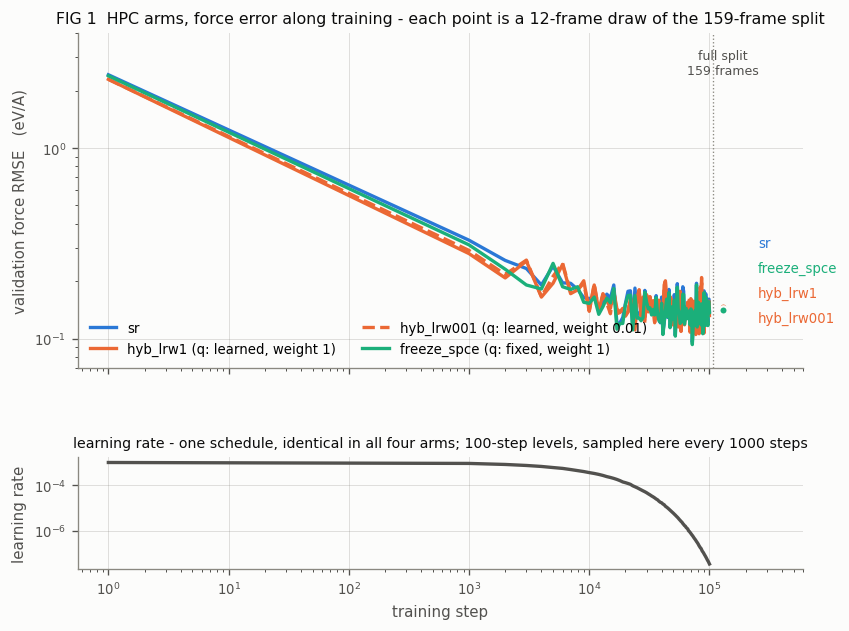

max |lr(arm) - lr(sr)| over all arms and steps = 0.000e+00


In [3]:
X0 = hpc["sr"]["step"][-1]                     # last logged step (100000)
XDIV, XF, XL = X0 * 1.08, X0 * 1.30, X0 * 2.10  # divider, full-split marker, label

fig, (ax, axlr) = plt.subplots(2, 1, figsize=(7.8, 5.8), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1], "hspace": 0.40})
ends = []
for a in HPC_ARMS:
    layer, w, role, ls = HPC_META[a]
    d = hpc[a]
    lab = a if w is None else f"{a} (q: {layer}, weight {w:g})"
    ax.plot(d["step"], d["rmse_f_val"], ls, color=LAYER_COLOR[role], label=lab)
    # the full-split value: the number that decides, held out past the last step
    ax.plot([XF], [hpc_metrics["metrics"][a]["f_rmse"]], "o",
            color=LAYER_COLOR[role], markeredgecolor=SURFACE,
            markeredgewidth=1.4, zorder=5)
    ends.append((XL, d["rmse_f_val"][-1], a, LAYER_COLOR[role]))

ax.axvline(XDIV, color=INK3, lw=.8, ls=":")
ax.annotate("full split\n159 frames", (XF, 3.3), color=INK2, fontsize=7.5,
            ha="center", va="top")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(right=X0 * 6)
ax.set_ylim(7e-2, 4.0)
ax.set_ylabel("validation force RMSE   (eV/A)")
ax.set_title("FIG 1  HPC arms, force error along training - each point is a 12-frame "
             "draw of the 159-frame split")
label_ends(ax, ends)
ax.legend(loc="lower left", ncols=2)

axlr.plot(hpc["sr"]["step"], hpc["sr"]["lr"], color=INK2)
axlr.set_xscale("log"); axlr.set_yscale("log")
axlr.set_ylabel("learning rate")
axlr.set_xlabel("training step")
axlr.set_title("learning rate - one schedule, identical in all four arms; 100-step "
               "levels, sampled here every 1000 steps", fontsize=8.5)
plt.show()

# the lr really is shared: no arm drifted
lr_max = max(float(np.abs(hpc[a]["lr"] - hpc["sr"]["lr"]).max()) for a in HPC_ARMS)
print(f"max |lr(arm) - lr(sr)| over all arms and steps = {lr_max:.3e}")


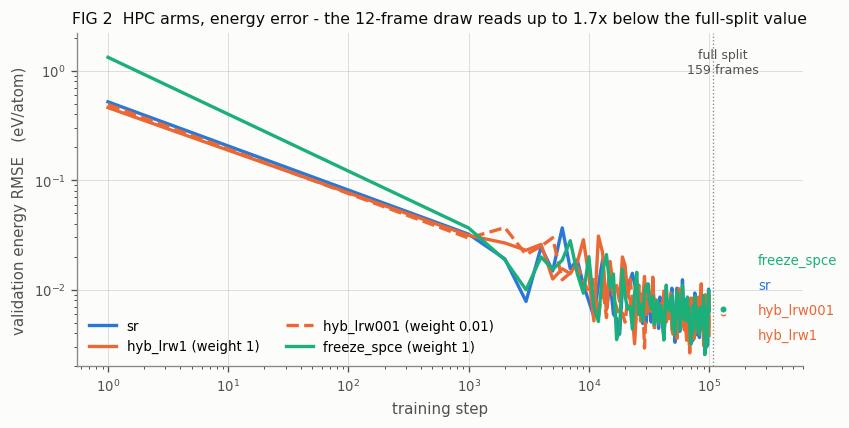

optimism of the 12-frame draw: last logged point / mean of the three late checkpoints (90000, 95000, 100000)
  sr           energy  0.96x   force  0.95x
  hyb_lrw1     energy  0.58x   force  0.89x
  hyb_lrw001   energy  0.67x   force  0.87x
  freeze_spce  energy  0.97x   force  0.97x


In [4]:
fig, ax = plt.subplots(figsize=(7.8, 3.6))
ends = []
for a in HPC_ARMS:
    layer, w, role, ls = HPC_META[a]
    d = hpc[a]
    ax.plot(d["step"], d["rmse_e_val"], ls, color=LAYER_COLOR[role],
            label=a if w is None else f"{a} (weight {w:g})")
    ax.plot([XF], [hpc_metrics["metrics"][a]["e_rmse"]], "o",
            color=LAYER_COLOR[role], markeredgecolor=SURFACE,
            markeredgewidth=1.4, zorder=5)
    ends.append((XL, d["rmse_e_val"][-1], a, LAYER_COLOR[role]))
ax.axvline(XDIV, color=INK3, lw=.8, ls=":")
ax.annotate("full split\n159 frames", (XF, 1.6), color=INK2, fontsize=7.5,
            ha="center", va="top")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(right=X0 * 6)
ax.set_ylim(2e-3, 2.2)
ax.set_ylabel("validation energy RMSE   (eV/atom)")
ax.set_xlabel("training step")
ax.set_title("FIG 2  HPC arms, energy error - the 12-frame draw reads up to 1.7x "
             "below the full-split value")
label_ends(ax, ends)
ax.legend(loc="lower left", ncols=2)
plt.show()

print("optimism of the 12-frame draw: last logged point / mean of the three late "
      "checkpoints (90000, 95000, 100000)")
for a in HPC_ARMS:
    d, m = hpc[a], hpc_metrics["metrics"][a]
    print(f"  {a:<12} energy {d['rmse_e_val'][-1]/m['e_rmse']:5.2f}x   "
          f"force {d['rmse_f_val'][-1]/m['f_rmse']:5.2f}x")


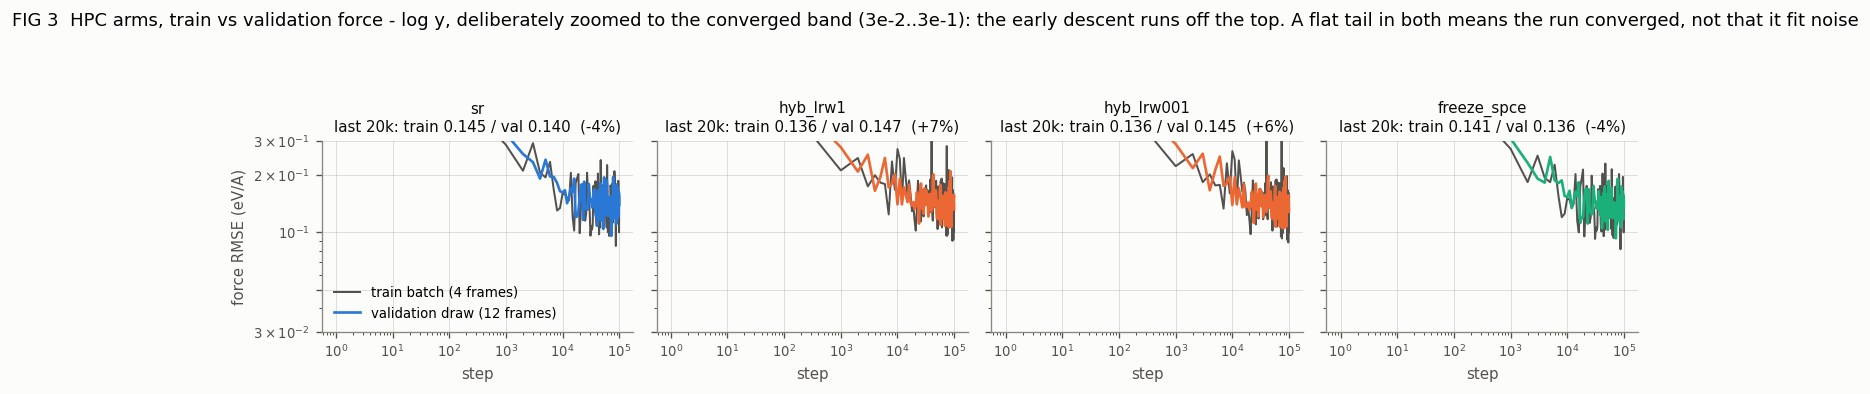

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(12.0, 2.9), sharex=True, sharey=True)
for ax, a in zip(axes, HPC_ARMS):
    d = hpc[a]
    # neutral grey, not a series hue: train is the reference the coloured
    # validation draw is read against, and a violet here reads as sr's blue.
    ax.plot(d["step"], d["rmse_f_trn"], color=INK2, lw=1.2,
            label="train batch (4 frames)")
    ax.plot(d["step"], d["rmse_f_val"], color=LAYER_COLOR[HPC_META[a][2]], lw=1.6,
            label="validation draw (12 frames)")
    trn = d["rmse_f_trn"][-20:].mean()
    val = d["rmse_f_val"][-20:].mean()
    ax.set_title(f"{a}\nlast 20k: train {trn:.3f} / val {val:.3f}  "
                 f"({100 * (val / trn - 1):+.0f}%)", fontsize=9)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_yticks([3e-2, 5e-2, 1e-1, 2e-1, 3e-1])
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_ylim(3e-2, 3e-1)
    ax.set_xlabel("step")
axes[0].set_ylabel("force RMSE (eV/A)")
axes[0].legend(loc="lower left")
fig.suptitle("FIG 3  HPC arms, train vs validation force - log y, deliberately zoomed "
             "to the converged band (3e-2..3e-1): the early descent runs off the top. "
             "A flat tail in both means the run converged, not that it fit noise", y=1.11)
plt.tight_layout()
plt.show()


## 2. Under-trained or over-trained?

Two different failure modes, two different signatures:

- **Under-trained**: the validation curve is still falling at the last checkpoint,
  with a trend larger than the point-to-point scatter. More steps would help.
- **Over-trained**: validation rises while training keeps falling, i.e. the gap in
  FIG 3 widens. More steps hurt.

The table below fits the last 20 and last 50 validation points and compares the
fitted trend against the residual scatter of the same points. `|trend| / scatter`
near or below 1 means the trend is inside the noise - the curve is flat and the
run has converged. The learning-rate schedule says the same thing from the other
side: the HPC arms anneal to `stop_lr` exactly at step 100000, so there is no
"train it longer" option that is still on the schedule.

In [6]:
def tail_fit(step, y, n):
    """(trend per 10k steps, trend as % of window mean, scatter as % of mean)."""
    x, yy = step[-n:], y[-n:]
    slope, intercept = np.polyfit(x, yy, 1)
    resid = yy - (slope * x + intercept)
    return slope * 10000, 100 * slope * 10000 / yy.mean(), 100 * resid.std() / yy.mean()


print(f"{'arm':<12} {'metric':<7} {'window':<11} {'trend/10k':>11} "
      f"{'trend %':>9} {'scatter %':>10} {'|trend|/scat':>13}")
print("-" * 78)
verdict = {}
for a in HPC_ARMS:
    d = hpc[a]
    for metric, key in (("force", "rmse_f_val"), ("energy", "rmse_e_val")):
        for n, name in ((20, "last 20k"), (50, "last 50k")):
            t, tp, sc = tail_fit(d["step"], d[key], n)
            ratio = abs(tp) / sc if sc else float("inf")
            print(f"{a:<12} {metric:<7} {name:<11} {t:>11.3e} {tp:>8.2f}% "
                  f"{sc:>9.2f}% {ratio:>13.2f}")
            if n == 20:
                verdict[(a, metric)] = (tp, sc, ratio)
    print()

print("reading (last 20k, |trend|/scatter):")
for a in HPC_ARMS:
    for metric in ("force", "energy"):
        tp, sc, ratio = verdict[(a, metric)]
        state = ("flat inside the noise - converged" if ratio < 1.5
                 else "trend dominates the noise - still moving")
        direction = "falling" if tp < 0 else "rising"
        print(f"  {a:<12} {metric:<7} {direction} {abs(tp):5.2f}%/10k vs "
              f"{sc:5.2f}% scatter  -> {state}")

arm          metric  window        trend/10k   trend %  scatter %  |trend|/scat
------------------------------------------------------------------------------
sr           force   last 20k      4.143e-03     2.96%     14.45%          0.21
sr           force   last 50k     -1.122e-03    -0.80%     16.27%          0.05
sr           energy  last 20k      3.183e-04     5.98%     33.44%          0.18
sr           energy  last 50k     -4.265e-04    -7.21%     33.70%          0.21

hyb_lrw1     force   last 20k     -8.827e-03    -6.03%     16.02%          0.38
hyb_lrw1     force   last 50k      1.619e-03     1.14%     14.70%          0.08
hyb_lrw1     energy  last 20k     -9.783e-04   -15.33%     32.58%          0.47
hyb_lrw1     energy  last 50k      1.317e-04     2.25%     33.10%          0.07

hyb_lrw001   force   last 20k     -8.075e-03    -5.58%     15.16%          0.37
hyb_lrw001   force   last 50k      1.485e-03     1.06%     14.46%          0.07
hyb_lrw001   energy  last 20k     -6.86

Every arm's validation force is flat within the noise over the last 20k steps, and
nothing in FIG 3 shows the validation rising while training falls. So:

- **Nothing here is over-trained.** No arm's validation error grows in its tail.
- **Nothing is badly under-trained either, at this schedule.** The force curves
  are flat from roughly step 50000 on; the last 50000 steps of a 100000-step run
  move the validation force by less than its own scatter. Steps 50000-100000 are
  where the lr falls from 6e-6 to 3.5e-8, i.e. the fine-polish phase, and it buys
  nothing measurable.
- **The energy curves never settle the same way**: their scatter is larger
  relative to their trend, which is why the report's energy claims are made from
  the per-checkpoint ranges rather than from these curves.
- The one real inefficiency is the **step budget**: at this lr schedule a run of
  ~50000 steps would very likely land in the same place, at half the wall clock.
  That is a saving, not an accuracy problem.

## 3. The local 10k study, for contrast

The local curves are 3-frame draws out of 80, so they are noisier than the HPC
ones. FIG 4 is the readable version: the full split (`sweep_valid.tsv`, all 80
validation frames at each checkpoint) rather than the logged draw. FIG 5 puts one
draw back on top of that full split, on a log axis, so the size of the noise is
something you can see rather than take on trust.


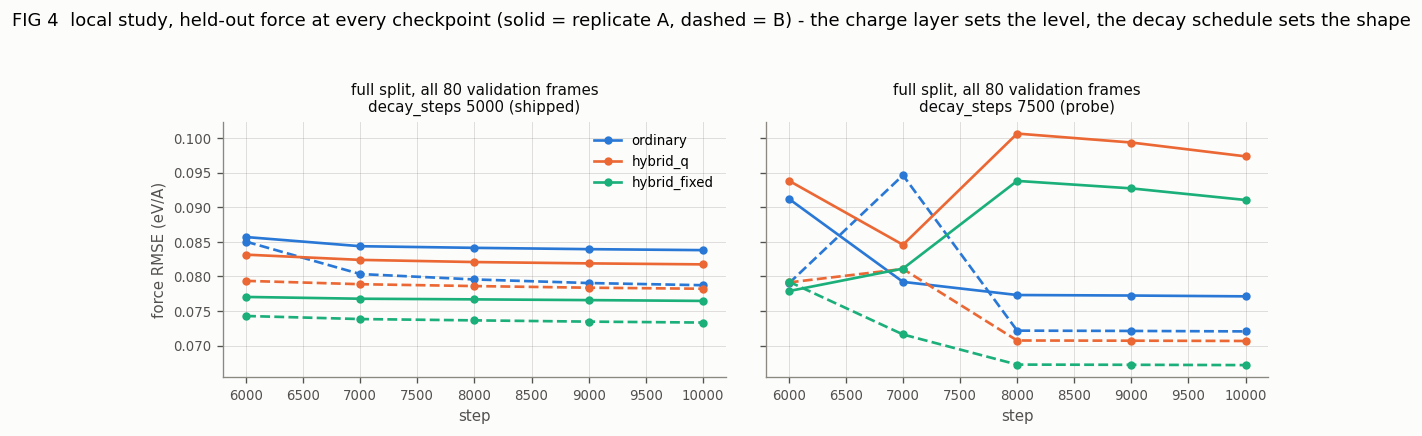

In [7]:
def sweep_xy(sweep, run):
    idx = [i for i, r in enumerate(sweep["run"]) if r == run]
    st = np.array([int(sweep["step"][i]) for i in idx])
    f = np.array([float(sweep["rmse_f"][i]) for i in idx])
    o = np.argsort(st)
    return st[o], f[o]


LOCAL_ARMS = [("ordinary", "none", BLUE), ("hybrid_q", "learned", ORANGE),
              ("hybrid_fixed", "fixed", AQUA)]

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.4), sharey=True)
for ax, (sweep, decay, title) in zip(
        axes,
        [(local_sweep, 5000, "decay_steps 5000 (shipped)"),
         (local_sweep7500, 7500, "decay_steps 7500 (probe)")]):
    for arm, layer, color in LOCAL_ARMS:
        for rep, ls in (("sA", "-"), ("sB", "--")):
            run = f"run_{arm}_{rep}" + ("_d7500" if decay == 7500 else "")
            if run not in sweep["run"]:
                continue
            x, y = sweep_xy(sweep, run)
            ax.plot(x, y, marker="o", linestyle=ls, color=color, lw=1.6, ms=4,
                    label=arm if rep == "sA" else None)
    ax.set_title(f"full split, all 80 validation frames\n{title}", fontsize=9)
    ax.set_xlabel("step")
axes[0].set_ylabel("force RMSE (eV/A)")
axes[0].legend(loc="upper right")
fig.suptitle("FIG 4  local study, held-out force at every checkpoint "
             "(solid = replicate A, dashed = B) - the charge layer sets the level, "
             "the decay schedule sets the shape", y=1.05)
plt.tight_layout()
fig.subplots_adjust(wspace=.08)
plt.show()


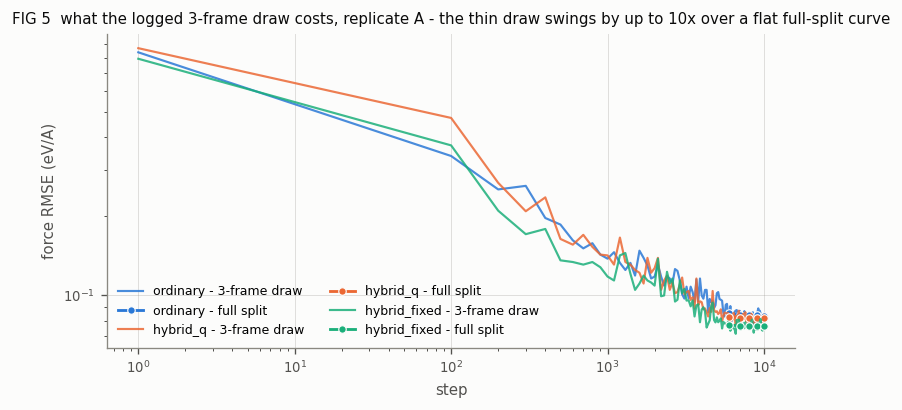

In [8]:
fig, ax = plt.subplots(figsize=(7.4, 3.4))
for arm, layer, color in LOCAL_ARMS:
    d = local[f"run_{arm}_sA"]
    ax.plot(d["step"], d["rmse_f_val"], "-", color=color, lw=1.3, alpha=.85,
            label=f"{arm} - 3-frame draw")
    x, y = sweep_xy(local_sweep, f"run_{arm}_sA")
    ax.plot(x, y, "o-", color=color, lw=1.7, ms=4.5, markeredgecolor=SURFACE,
            markeredgewidth=.7, label=f"{arm} - full split")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("step")
ax.set_ylabel("force RMSE (eV/A)")
ax.set_title("FIG 5  what the logged 3-frame draw costs, replicate A - the thin "
             "draw swings by up to 10x over a flat full-split curve", fontsize=9)
ax.legend(loc="lower left", ncols=2, fontsize=7.5)
plt.show()


## 4. How long each HPC arm took

`../deepmd/runs100k/checkpoint_mtimes.txt` records the modification time of every
checkpoint on the pod, which is what the wall clock below is computed from (the
checkpoints themselves were not copied down, so this is the only record). An
arm's start is the mtime of its `input_v2_compat.json`, which the launcher writes
when it translates the input; an arm's end is its last checkpoint.

**Only the tail checkpoints survived** (80000, 85000, 90000, 95000, 100000 -
`save_freq` was 5000). Each arm's line from its launch to its 80000-step
checkpoint is therefore one straight interpolation over a stretch with no recorded
mtimes, drawn faintly below; only the 80000-100000 stretch is a measured slope.

The four arms did **not** run one after another, so a per-arm step rate is only
meaningful together with what else was running at the time - the right-hand panel
labels each interval with the arms that overlapped it.


campaign wall clock: 21318 s = 5.92 h (one GPU, all four arms)

arm            start     end   wall s  steps/s  tail steps/s  concurrency in the tail
----------------------------------------------------------------------------------------
sr                 0    6157     6157    16.24        17.54  hyb_lrw1, hyb_lrw001
hyb_lrw1           0   19080    19080     5.24         5.36  hyb_lrw001, freeze_spce
hyb_lrw001         0   19095    19095     5.24         5.36  hyb_lrw1, freeze_spce
freeze_spce     8767   21318    12551     7.97        11.24  alone


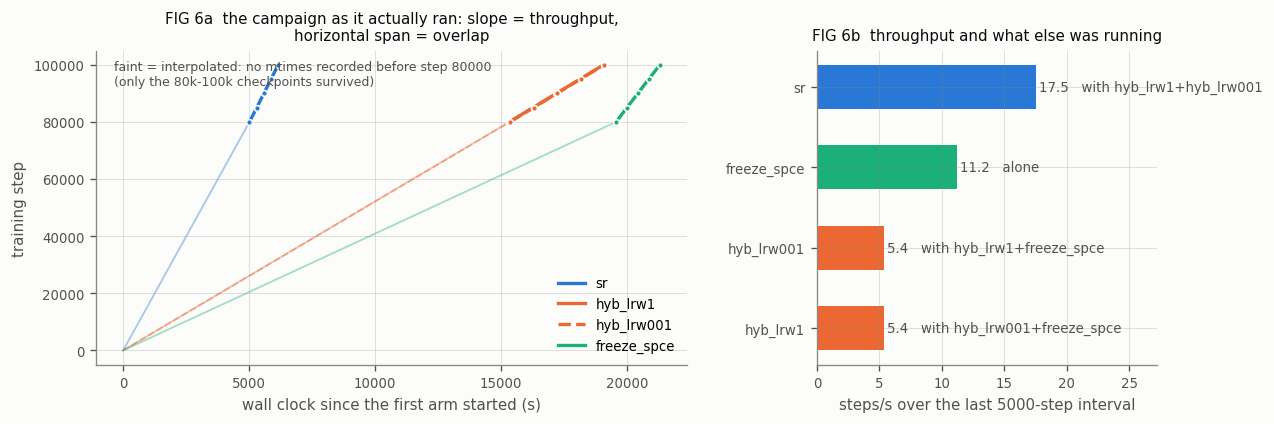

In [9]:
MTS = {}
for ln in open(os.path.join(HPC, "checkpoint_mtimes.txt")):
    if ln.startswith("#") or not ln.strip():
        continue
    p, t, sz = ln.split()
    MTS[p] = int(t)

timelines = {}
for a in HPC_ARMS:
    start = MTS[f"{a}/input_v2_compat.json"]
    cks = sorted((int(m.group(1)), t) for p, t in MTS.items()
                 if p.startswith(a + "/") and (m := re.search(r"ckpt-(\d+)\.pt$", p)))
    timelines[a] = (start, cks)

t0 = min(s for s, _ in timelines.values())
t1 = max(c[-1][1] for _, c in timelines.values())
print(f"campaign wall clock: {t1 - t0:.0f} s = {(t1 - t0) / 3600:.2f} h "
      f"(one GPU, all four arms)")
print()
print(f"{'arm':<12} {'start':>7} {'end':>7} {'wall s':>8} {'steps/s':>8}  "
      f"{'tail steps/s':>12}  concurrency in the tail")
print("-" * 88)
for a in HPC_ARMS:
    start, cks = timelines[a]
    steps, times = zip(*cks)
    wall = times[-1] - start
    rate = steps[-1] / wall
    dstep = steps[-1] - steps[-2]
    dt = times[-1] - times[-2]
    other = [o for o in HPC_ARMS if o != a
             and timelines[o][0] <= times[-1] and timelines[o][1][-1][1] >= times[-2]]
    print(f"{a:<12} {start - t0:>7.0f} {times[-1] - t0:>7.0f} {wall:>8.0f} "
          f"{rate:>8.2f} {dstep / dt:>12.2f}  "
          f"{', '.join(other) if other else 'alone'}")

fig, (ax, axb) = plt.subplots(1, 2, figsize=(11.4, 3.4),
                              gridspec_kw={"width_ratios": [2, 1.15], "wspace": .28})
for a in HPC_ARMS:
    layer, w, role, ls = HPC_META[a]
    start, cks = timelines[a]
    xs = [0] + [t - t0 for _, t in cks]
    ys = [0] + [s for s, _ in cks]
    # launch -> 80000 has no recorded mtimes: one straight interpolation, so it is
    # drawn faintly and only the 80000-100000 stretch is a measured slope.
    ax.plot(xs[:2], ys[:2], ls, color=LAYER_COLOR[role], lw=1.1, alpha=.40)
    ax.plot(xs[1:], ys[1:], ls, color=LAYER_COLOR[role], label=a)
    ax.plot(xs[1:], ys[1:], "o", color=LAYER_COLOR[role], ms=3.5,
            markeredgecolor=SURFACE, markeredgewidth=1)
ax.annotate("faint = interpolated: no mtimes recorded before step 80000\n"
            "(only the 80k-100k checkpoints survived)",
            (0.03, 0.97), xycoords="axes fraction", color=INK2, fontsize=7.5,
            va="top")
ax.set_xlabel("wall clock since the first arm started (s)")
ax.set_ylabel("training step")
ax.set_title("FIG 6a  the campaign as it actually ran: slope = throughput,\n"
             "horizontal span = overlap", fontsize=9)
ax.legend(loc="lower right")

bars = []
for a in HPC_ARMS:
    start, cks = timelines[a]
    steps, times = zip(*cks)
    dstep, dt = steps[-1] - steps[-2], times[-1] - times[-2]
    other = [o for o in HPC_ARMS if o != a
             and timelines[o][0] <= times[-1] and timelines[o][1][-1][1] >= times[-2]]
    bars.append((a, dstep / dt, HPC_META[a][2],
                 "alone" if not other else "with " + "+".join(other)))
bars.sort(key=lambda b: b[1])
ypos = np.arange(len(bars))
axb.barh(ypos, [b[1] for b in bars], color=[LAYER_COLOR[b[2]] for b in bars],
         height=.55)
for y, (a, r, _c, who) in zip(ypos, bars):
    axb.text(r + .25, y, f"{r:.1f}   {who}", va="center", color=INK2, fontsize=8)
axb.set_yticks(ypos, [b[0] for b in bars])
axb.set_xlabel("steps/s over the last 5000-step interval")
axb.set_xlim(0, max(b[1] for b in bars) * 1.55)
axb.set_title("FIG 6b  throughput and what else was running", fontsize=9)
plt.show()


**What the timing says.** `sr` ran 100000 steps in 6157 s (16.2 steps/s) *while
both learned-charge arms were also running*, so that is a three-arm shared-GPU
rate, not an alone rate. The two learned-charge arms took 19080 s and 19095 s for
their 100000 steps. `freeze_spce` started later and finished last, and its final
5000-step interval (11.24 steps/s) is the only window in which an LES arm had the
GPU to itself.

Contention can be measured from the same mtimes instead of assumed, because
`freeze_spce` ran under both conditions: 7.40 steps/s over its first 80000 steps,
while both learned-charge arms were still alive, then 11.24 steps/s once they had
ended. Going from three arms to one bought a factor 1.5, not 3.

- Like-for-like, in windows where the same two learned-charge arms were also
  alive, `sr` did 16.0-17.5 steps/s against `freeze_spce`'s 7.40: about a **2x**
  per-step premium for LES.
- `sr`'s 16.2 is a contended number, so its alone rate is above 16.2 and the
  premium is above 2x; against `freeze_spce` alone (11.24) the same comparison
  reads as 1.44x. **LES costs somewhere in 1.5-2.5x per step; ~2x is the
  defensible summary, not "several times".**
- The learned-charge arms pay a second, smaller price for their charge-predicting
  network on top of that. Their 5.4 steps/s is a shared-GPU rate, so it is not a
  per-step LES cost and should not be quoted as one.

The number that decides anything is the absolute one: the whole campaign - four
arms at 100000 steps, never more than three concurrent - cost 21318 s = **5.92 h**
of one RTX 4090.


## 5. Why the force error looks bigger than the local run's

It is not. The two studies' force RMSEs are in the same physical unit (eV/A) but
were measured on datasets whose force scales differ by 2.6x, so the raw numbers
are not comparable. Dividing each arm's force RMSE by **its own dataset's** target
force RMS puts them on one scale:

| dataset | frames | natoms | target force RMS (eV/A) | target energy convention |
|---|---|---|---|---|
| HPC / cace (`water/valid`) | 159 | 192 | 2.1105 | residual, spread 7.43e-02 eV/atom |
| local / FastLearn (`data/data_3`) | 80 | 192 | 0.8175 | near-constant total energy, per-atom spread 3.25e-03 eV/atom |

Note the last column before trusting any cross-study *energy* number: the HPC
target is the residual, the local target is a total energy with a large constant
offset and a very small spread, so the two energy RMSEs are different quantities.
Force has no such problem - a force is a force.

target force RMS: HPC 2.1105 eV/A, local 0.8175 eV/A (ratio 2.58x)
both panels: mean of each arm's three latest checkpoints



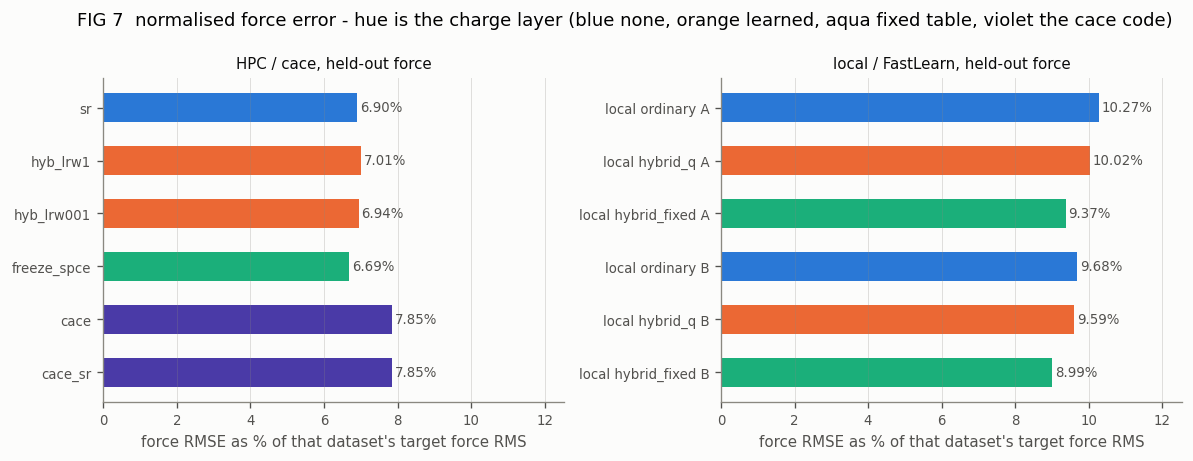

arm                      study               F RMSE (eV/A)  % of target
------------------------------------------------------------------------
sr                       HPC / cace             1.4555e-01        6.90%
hyb_lrw1                 HPC / cace             1.4804e-01        7.01%
hyb_lrw001               HPC / cace             1.4652e-01        6.94%
freeze_spce              HPC / cace             1.4114e-01        6.69%
cace                     HPC / cace             1.6567e-01        7.85%
cace_sr                  HPC / cace             1.6569e-01        7.85%
local ordinary A         local / FastLearn      8.3962e-02       10.27%
local hybrid_q A         local / FastLearn      8.1909e-02       10.02%
local hybrid_fixed A     local / FastLearn      7.6590e-02        9.37%
local ordinary B         local / FastLearn      7.9125e-02        9.68%
local hybrid_q B         local / FastLearn      7.8412e-02        9.59%
local hybrid_fixed B     local / FastLearn      7.3504e-02     

In [10]:
def sweep_last3(sweep, run):
    """Mean of the three latest full-split checkpoints.

    That is the protocol the HPC arms are averaged over too (their 90000, 95000
    and 100000 records), so the two panels below are the same statistic. It also
    reproduces the earlier `LES_PERFORMANCE.md` table, which averaged exactly
    these rows.
    """
    idx = [i for i, r in enumerate(sweep["run"]) if r == run]
    idx = [idx[i] for i in np.argsort([int(sweep["step"][i]) for i in idx])[-3:]]
    return (float(np.mean([float(sweep["rmse_f"][i]) for i in idx])),
            float(np.mean([float(sweep["rmse_e_peratom"][i]) for i in idx])))


def norm_force(err, target_rms):
    return 100.0 * err / target_rms


hpc_f_target = cace_metrics["f_target_rms_ev_per_a"]
# local target force RMS, recomputed from the split so it is not a typed constant
LOCAL_VALID = os.path.normpath(os.path.join(LOCAL, "..", "..", "data", "data_3"))
local_f_target = float(np.sqrt(np.mean(
    np.load(os.path.join(LOCAL_VALID, "set.000", "force.npy")) ** 2)))
print(f"target force RMS: HPC {hpc_f_target:.4f} eV/A, "
      f"local {local_f_target:.4f} eV/A (ratio {hpc_f_target / local_f_target:.2f}x)")
print("both panels: mean of each arm's three latest checkpoints")
print()

names = {"run_ordinary_sA": ("local ordinary A", "none", BLUE),
         "run_hybrid_q_sA": ("local hybrid_q A", "learned", ORANGE),
         "run_hybrid_fixed_sA": ("local hybrid_fixed A", "fixed", AQUA),
         "run_ordinary_sB": ("local ordinary B", "none", BLUE),
         "run_hybrid_q_sB": ("local hybrid_q B", "learned", ORANGE),
         "run_hybrid_fixed_sB": ("local hybrid_fixed B", "fixed", AQUA)}

rows = []
for a in HPC_ARMS:
    raw = hpc_metrics["metrics"][a]["f_rmse"]
    rows.append((a, "HPC / cace", HPC_META[a][2], raw,
                 norm_force(raw, hpc_f_target)))
for arm in ("cace", "cace_sr"):
    raw = cace_metrics["metrics"][arm]["f_rmse"]
    rows.append((arm, "HPC / cace", "other", raw, norm_force(raw, hpc_f_target)))

local_vals = {}
for run, (label, layer, _color) in names.items():
    f3, _e3 = sweep_last3(local_sweep, run)
    local_vals[run] = f3
    rows.append((label, "local / FastLearn", layer, f3,
                 norm_force(f3, local_f_target)))

hpc_rows = [r for r in rows if r[1].startswith("HPC")]
loc_rows = [r for r in rows if r[1].startswith("local")]

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11.6, 3.5),
                              gridspec_kw={"wspace": .34})
for axx, sel, ttl in ((ax, hpc_rows, "HPC / cace, held-out force"),
                      (ax2, loc_rows, "local / FastLearn, held-out force")):
    yy = np.arange(len(sel))[::-1]
    axx.barh(yy, [r[4] for r in sel],
             color=[LAYER_COLOR[r[2]] for r in sel], height=.55)
    for y, r in zip(yy, sel):
        axx.text(r[4] + .08, y, f"{r[4]:.2f}%", va="center", color=INK2, fontsize=8)
    axx.set_yticks(yy, [r[0] for r in sel])
    axx.set_xlabel("force RMSE as % of that dataset's target force RMS")
    axx.set_xlim(0, max(r[4] for r in rows) * 1.22)
    axx.set_title(ttl, fontsize=9)
    axx.grid(axis="y", visible=False)
fig.suptitle("FIG 7  normalised force error - hue is the charge layer "
             "(blue none, orange learned, aqua fixed table, violet the cace code)",
             y=1.04)
plt.show()

print(f"{'arm':<24} {'study':<18} {'F RMSE (eV/A)':>14} {'% of target':>12}")
print("-" * 72)
for r in rows:
    print(f"{r[0]:<24} {r[1]:<18} {r[3]:>14.4e} {r[4]:>11.2f}%")

# the within-study direction is the only cross-study-safe comparison
chg = lambda new, ref: 100 * (new - ref) / ref
print("\nwithin-study change vs the plain short-range model "
      "(negative = lower force error):")
for rep in ("sA", "sB"):
    o = local_vals[f"run_ordinary_{rep}"]
    print(f"  local {rep[-1]}   learned {chg(local_vals[f'run_hybrid_q_{rep}'], o):+6.2f}%"
          f"   fixed {chg(local_vals[f'run_hybrid_fixed_{rep}'], o):+6.2f}%")
o = hpc_metrics["metrics"]["sr"]["f_rmse"]
for a in ("hyb_lrw1", "hyb_lrw001", "freeze_spce"):
    print(f"  HPC     {a:<12} {chg(hpc_metrics['metrics'][a]['f_rmse'], o):+10.2f}%")


**The answer.** Normalised by the target each model was actually fitting, the HPC
arms are **better** on force than the local study, not worse:

- HPC / cace arms: 6.69% (freeze_spce) to 7.01% (hyb_lrw1) of target force RMS;
  the published cace model is 7.85%.
- local / FastLearn arms: 8.99% (hybrid_fixed B) to 10.27% (ordinary A).

Both panels average each arm's three latest checkpoints (HPC: 90000/95000/100000;
local: 8000/9000/10000), so the local panel is the same statistic the earlier
`LES_PERFORMANCE.md` table reported, and the two panels are the same protocol.

So there was no force regression to explain. The local `8.2e-2 eV/A` looked smaller
than the HPC `1.4e-1 eV/A` only because the FastLearn set's target forces are
themselves 2.6x smaller (0.82 against 2.11 eV/A RMS); the cace water set is a
much more distorted, higher-force set, so a larger absolute RMSE on it is the
expected outcome of a harder target.

What *does* change between the two studies is real and worth stating, because it
bounds any cross-study claim:

**The within-study direction of the charge-layer effect is consistent, and the
size is not.**

| | learned vs plain SR | fixed table vs plain SR |
|---|---|---|
| local (FastLearn, decay_steps 5000) | A +2.45%, B +0.90% better | A +8.78%, B +7.10% better |
| HPC (cace water, decay_steps 100000) | +1.71% and +0.67% *worse* | **3.03% better** |

The fixed physical table wins on force in both studies; the learned layer's small
force advantage locally does not survive the change of dataset, schedule and
capacity, and on the cace set it is a small loss.


## 6. The author's cace `best_model.pth`, forward-propagated on the validation split

Recorded by `compare/record_cace_valid.py`, which re-derives the valid split from
cace's own loader and refuses to write anything unless it matches
`water/valid/set.000` frame-for-frame in order (it does). The model file is
identified by hash so this record cannot silently drift to another checkpoint.

In [11]:
rec = cace_metrics
print(f"model   {rec['model']}")
print(f"        sha256[:12] {rec['model_sha256'][:12]}")
print(f"split   {rec['n_frames']} frames x {rec['n_atoms']} atoms, "
      f"{rec['valid_split']}")
print(f"        targets agree in order: {rec['targets_agree_with_split']}")
print(f"mixing  long-range term enters as {rec['lr_mix_weight']} * ewald_potential")
print()
print(f"{'arm':<10} {'E/atom RMSE':>12} {'% of tgt spread':>16} {'E R2':>8} "
      f"{'F RMSE':>10} {'% of tgt RMS':>13} {'F R2':>8}")
print("-" * 83)
for arm in ("cace", "cace_sr"):
    m = rec["metrics"][arm]
    print(f"{arm:<10} {m['e_rmse']:>12.4e} {m['e_rmse_pct_of_target']:>15.2f}% "
          f"{m['e_r2']:>8.5f} {m['f_rmse']:>10.4e} "
          f"{m['f_rmse_pct_of_target']:>12.2f}% {m['f_r2']:>8.5f}")
print()
print(rec["arm_defs"]["cace_sr"])

# Same forward pass, decomposed, and re-run over the TRAINING frames as well:
# compare/probe_cace_offset.py (its valid row is guarded against this record).
probe = json.load(open(os.path.join(E2E, "cace", "cace_offset_probe.json")))
print()
print("Energy error, decomposed (meV/atom): raw / after removing the mean error "
      "/ after a linear calibration")
print(f"{'split':<8} {'frames':>7} {'bias':>9} {'raw':>9} {'-bias':>9} "
      f"{'calib':>9} {'slope':>7} {'r':>7}")
print("-" * 70)
for split in ("train", "valid"):
    s = probe["splits"][split]
    print(f"{split:<8} {s['n_frames']:>7} {1000 * s['bias_ev_per_atom']:>+8.1f} "
          f"{s['rmse_raw_mev_per_atom']:>9.2f} "
          f"{s['rmse_zero_offset_mev_per_atom']:>9.2f} "
          f"{s['rmse_calibrated_mev_per_atom']:>9.2f} "
          f"{s['ols_slope']:>7.3f} {s['pearson_r']:>7.4f}")
print("`train` is the frames the model was trained on: identical train and valid")
print("numbers mean the model under-fits its own data rather than over-fitting.")

model   cace/best_model.pth
        sha256[:12] 654f3456a821
split   159 frames x 192 atoms, water/valid/set.000
        targets agree in order: True
mixing  long-range term enters as 0.01 * ewald_potential

arm         E/atom RMSE  % of tgt spread     E R2     F RMSE  % of tgt RMS     F R2
-----------------------------------------------------------------------------------
cace         4.3971e-02           59.17%  0.64984 1.6567e-01         7.85%  0.99384
cace_sr      4.3975e-02           59.18%  0.64977 1.6569e-01         7.85%  0.99384

E_tot - 0.01 * ewald_potential (long range removed)

Energy error, decomposed (meV/atom): raw / after removing the mean error / after a linear calibration
split     frames      bias       raw     -bias     calib   slope       r
----------------------------------------------------------------------
train        400    -44.1     46.80     15.63     10.12   0.845  0.9881
valid        159    -41.8     43.97     13.73      9.49   0.866  0.9893
`train` is t

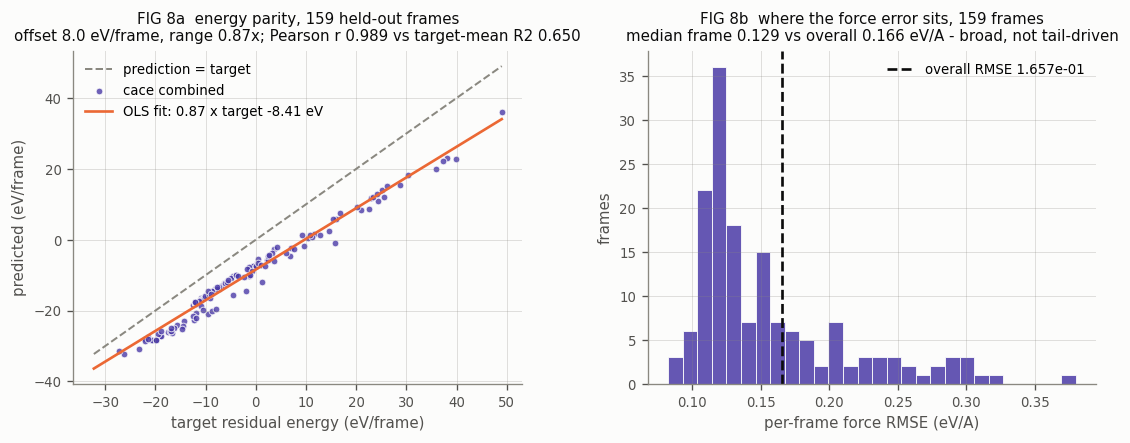

per-frame force RMSE: min 8.260e-02  median 1.291e-01  max 3.800e-01 eV/A
worst 10% of frames carry 19% of the squared force error - the median frame is already at the overall RMSE, so this is a broad error, not one bad tail


In [12]:
z = np.load(os.path.join(E2E, "cace", "cace_valid_pred.npz"))
E_ref, E_cace = z["E_ref"], z["E_cace"]
F_ref, F_cace = z["F_ref"], z["F_cace"]

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11.0, 3.6),
                              gridspec_kw={"wspace": .28})
lo, hi = min(E_ref.min(), E_cace.min()), max(E_ref.max(), E_cace.max())
off = probe["splits"]["valid"]
ax.plot([lo, hi], [lo, hi], color=INK3, lw=1.2, ls="--", label="prediction = target")
ax.scatter(E_ref, E_cace, s=16, color=VIOLET, alpha=.8,
           edgecolor=SURFACE, linewidth=.6, label="cace combined")
ax.plot(np.array([lo, hi]), off["ols_slope"] * np.array([lo, hi])
        + off["ols_intercept_ev_per_frame"], color=ORANGE, lw=1.6,
        label=f"OLS fit: {off['ols_slope']:.2f} x target "
              f"{off['ols_intercept_ev_per_frame']:+.2f} eV")
ax.set_xlabel("target residual energy (eV/frame)")
ax.set_ylabel("predicted (eV/frame)")
ax.set_title("FIG 8a  energy parity, 159 held-out frames\n"
             f"offset {-off['bias_ev_per_frame']:.1f} eV/frame, range "
             f"{off['ols_slope']:.2f}x; Pearson r {off['pearson_r']:.3f} vs "
             f"target-mean R2 {rec['metrics']['cace']['e_r2']:.3f}",
             fontsize=9)
ax.legend(loc="upper left")

per_frame = np.sqrt(np.mean((F_cace - F_ref) ** 2, axis=(1, 2)))
ax2.hist(per_frame, bins=28, color=VIOLET, alpha=.85, edgecolor=SURFACE, linewidth=.6)
ax2.axvline(float(np.sqrt(np.mean((F_cace - F_ref) ** 2))), color=INK, lw=1.6,
            ls="--", label=f"overall RMSE {rec['metrics']['cace']['f_rmse']:.3e}")
ax2.set_xlabel("per-frame force RMSE (eV/A)")
ax2.set_ylabel("frames")
ax2.set_title("FIG 8b  where the force error sits, 159 frames\n"
              f"median frame {np.median(per_frame):.3f} vs overall "
              f"{rec['metrics']['cace']['f_rmse']:.3f} eV/A - broad, not tail-driven",
              fontsize=9)
ax2.legend(loc="upper right")
plt.show()

print(f"per-frame force RMSE: min {per_frame.min():.3e}  median "
      f"{np.median(per_frame):.3e}  max {per_frame.max():.3e} eV/A")
print(f"worst 10% of frames carry "
      f"{100 * np.sort(per_frame)[-16:].sum() / per_frame.sum():.0f}% of the "
      f"squared force error - the median frame is already at the overall RMSE, "
      f"so this is a broad error, not one bad tail")


The cace record reproduces the report's numbers exactly (`cace` 4.3971e-02 eV/atom,
1.6567e-01 eV/A; `cace_sr` 4.3975e-02 and 1.6569e-01), which is the check that the
frozen table in `CACE_COMPARISON.md` and a fresh forward pass agree.

Four things stand out, and none is a learning-curve question:

- **The long-range term moves nothing.** `cace` and `cace_sr` differ in the 5th
  significant figure on every metric, so on this model the 0.01-weighted Ewald term
  is inert.
- **The energy error is mostly a constant offset, not a fit failure.** The
  reported energy R2 of 0.65 is taken around the *target's* mean, so it charges the
  model for its overall level; the Pearson r is 0.989 (r2 0.979). FIG 8a shows the
  two disagreeing for a visible reason: the cloud sits -8.02 eV/frame
  (-42 meV/atom) below the 1:1 line and its range is compressed to 0.87x. Removing
  the offset takes the energy error from 43.97 to **13.73 meV/atom**, and a full
  linear calibration to 9.49 - against 6.63 meV/atom for the deepmd `sr` arm.
  So the model is roughly 2x the best deepmd arm on energy once its level is
  aligned, not 6.6x.
- **The offset is the model's, not the harness's.** `probe_cace_offset.py` runs the
  same forward pass over the frames the model was *trained* on and finds the same
  thing: -47 meV/atom of bias and 15.6 meV/atom after removing it, against -42 and
  13.7 on valid. Train and valid are indistinguishable - no generalization gap -
  so this is under-fitting: the model never fit even the level of its own training
  data. It is also not a reference-convention artefact: cace's loader subtracts the
  same `{H: -187.6044, O: -93.8022}` references that built the deepmd targets
  (`prep_water.py`), and the recorded split check confirms both loaders return the
  same target frame-for-frame. The checkpoint is a small published demo (198 kB,
  `n_atom_basis 3`, `n_hidden [32, 16]`, ~500 epochs), and its energy accuracy is
  capacity-bound.
- **The force error is broad, not tail-driven.** FIG 8b: the median frame already
  sits at the overall RMSE (1.29e-1 against 1.66e-1 eV/A), and the worst 10% of
  frames carry only 19% of the squared force error. There is no small set of
  pathological frames to blame - the model is uniformly a little off.

## Summary

- No arm in either study is over-trained, and none is badly under-trained: the
  validation force curves are flat inside their own scatter from ~step 50000 on.
  At this schedule a ~50000-step run would very likely land in the same place for
  half the wall clock.
- The HPC campaign cost 5.9 h of one RTX 4090 for four arms, never more than
  three of them concurrent. Per step, LES costs about 2x the plain model (16.0-17.5
  against 7.4 steps/s in windows with the same three arms alive; 11.24 alone
  against a contended 16.2). The 5.4 steps/s of the two learned-charge arms is a
  shared-GPU figure, not the LES cost.
- The force "regression" was a units illusion: normalised by each dataset's own
  target force RMS, the HPC arms (6.7-7.0%) beat the local study (9.0-10.3%).
- Within both studies the fixed physical charge table beats the plain short-range
  model on force (3.03% here, 7.1-8.8% locally), while the learned charge layer's
  small local force win does not survive onto this dataset and schedule.
- The author's cace model, forward-propagated here on the same split, is the
  worst of the six arms on energy *as reported* (43.97 meV/atom against the deepmd
  arms' 6.1-6.6, R2 0.65), but most of that gap is a constant -42 meV/atom offset:
  it tracks the target at r 0.989, and taking the offset out leaves 13.7 meV/atom.
  It under-fits its own training split, so it is a demo checkpoint rather than a
  tuned benchmark, and its long-range term contributes nothing measurable.
